In [12]:
import pandas as pd
import numpy as np

# ============================================================
# BLOCO 1 — CARREGAR DADOS E PREPARAR PARA ANÁLISE
# ============================================================

# Carregar KPIs dos 3 setores
kpis_fin = pd.read_csv("../KPIs/kpis_financeiro.csv", sep=";", encoding="utf-8", keep_default_na=False)
kpis_en  = pd.read_csv("../KPIs/kpis_energia.csv",    sep=";", encoding="utf-8", keep_default_na=False)
kpis_pet = pd.read_csv("../KPIs/kpis_petroleo.csv",   sep=";", encoding="utf-8", keep_default_na=False)

# Colunas numéricas por setor
cols_fin = ['roe', 'margem_liquida', 'nim', 'indice_eficiencia', 'alavancagem', 'pdd_ratio']
cols_en  = ['roe', 'margem_liquida', 'margem_bruta', 'margem_ebitda', 'alavancagem', 'cobertura_juros']
cols_pet = ['roe', 'margem_liquida', 'margem_bruta', 'margem_ebitda', 'alavancagem', 'cobertura_juros']

# Converter para numérico — strings vazias viram NaN
for col in cols_fin:
    kpis_fin[col] = pd.to_numeric(kpis_fin[col], errors='coerce')
for col in cols_en:
    kpis_en[col] = pd.to_numeric(kpis_en[col], errors='coerce')
for col in cols_pet:
    kpis_pet[col] = pd.to_numeric(kpis_pet[col], errors='coerce')

print("=== SHAPE DOS DATASETS ===")
print(f"Financeiro: {kpis_fin.shape}")
print(f"Energia:    {kpis_en.shape}")
print(f"Petróleo:   {kpis_pet.shape}")

print("\n=== TIPOS DAS COLUNAS FINANCEIRO ===")
print(kpis_fin[cols_fin].dtypes)

=== SHAPE DOS DATASETS ===
Financeiro: (90, 12)
Energia:    (90, 12)
Petróleo:   (39, 12)

=== TIPOS DAS COLUNAS FINANCEIRO ===
roe                  float64
margem_liquida       float64
nim                  float64
indice_eficiencia    float64
alavancagem          float64
pdd_ratio            float64
dtype: object


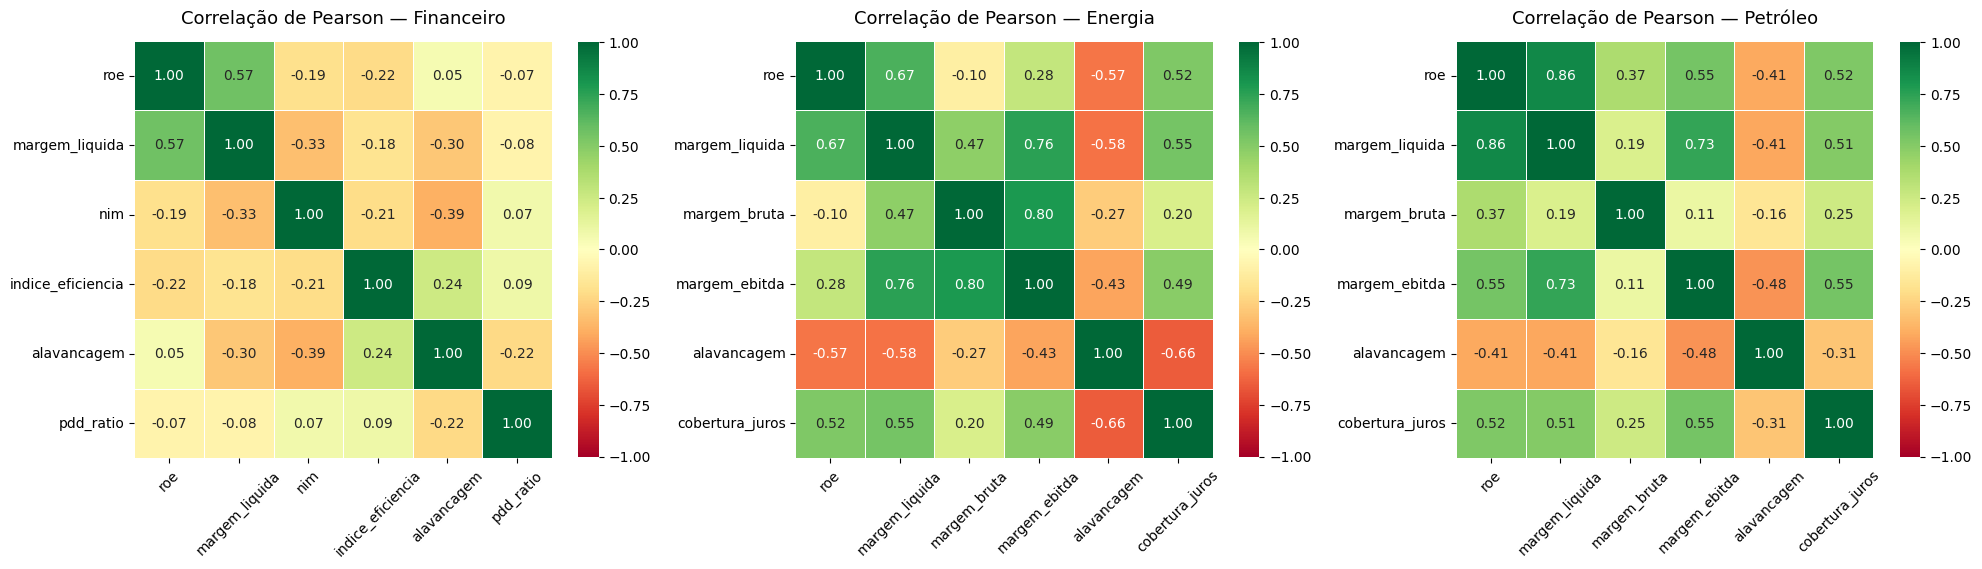

Gráfico salvo em KPIs/correlacao_pearson.png


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ============================================================
# BLOCO 2 — CORRELAÇÃO DE PEARSON POR SETOR
# Mede a relação linear entre cada par de KPIs
# Varia de -1 (correlação negativa perfeita) a
#          +1 (correlação positiva perfeita)
#           0 = sem correlação linear
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

setores = [
    ('Financeiro', kpis_fin, cols_fin, axes[0]),
    ('Energia',    kpis_en,  cols_en,  axes[1]),
    ('Petróleo',   kpis_pet, cols_pet, axes[2]),
]

for nome, df, cols, ax in setores:
    # Calcular matriz de correlação
    corr = df[cols].corr(method='pearson')
    
    # Plotar heatmap
    sns.heatmap(
        corr,
        ax=ax,
        annot=True,           # mostrar valores
        fmt='.2f',            # 2 casas decimais
        cmap='RdYlGn',        # vermelho = negativo, verde = positivo
        vmin=-1, vmax=1,      # escala fixa
        center=0,
        square=True,
        linewidths=0.5,
        cbar_kws={'shrink': 0.8}
    )
    ax.set_title(f'Correlação de Pearson — {nome}', fontsize=13, pad=12)
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('../KPIs/correlacao_pearson.png', dpi=150, bbox_inches='tight')
plt.show()

print("Gráfico salvo em KPIs/correlacao_pearson.png")

In [14]:
# ============================================================
# BLOCO 3 — TESTE DE WILCOXON (Mann-Whitney U)
# Compara distribuições de estatais vs privados
# Não assume normalidade — ideal para amostras pequenas
# H0: estatais e privados têm a mesma distribuição
# H1: distribuições são diferentes
# p-valor < 0.05 → diferença estatisticamente significativa
# ============================================================

from scipy.stats import mannwhitneyu

resultados = []

for nome, df, cols in [
    ('Financeiro', kpis_fin, cols_fin),
    ('Energia',    kpis_en,  cols_en),
    ('Petróleo',   kpis_pet, cols_pet),
]:
    estatais = df[df['tipo'] == 'Estatal']
    privados = df[df['tipo'] == 'Privado']
    
    for kpi in cols:
        # Extrair valores válidos de cada grupo
        g1 = estatais[kpi].dropna()
        g2 = privados[kpi].dropna()
        
        # Teste Mann-Whitney U (equivalente não-paramétrico do Teste T)
        stat, p = mannwhitneyu(g1, g2, alternative='two-sided')
        
        # Calcular diferença de medianas para saber direção
        diff_mediana = g1.median() - g2.median()
        
        resultados.append({
            'setor':          nome,
            'kpi':            kpi,
            'mediana_estatal':round(g1.median(), 4),
            'mediana_privado':round(g2.median(), 4),
            'diff_mediana':   round(diff_mediana, 4),
            'p_valor':        round(p, 4),
            'significativo':  'Sim ✅' if p < 0.05 else 'Não ❌',
        })

resultado_df = pd.DataFrame(resultados)
print("=== TESTE MANN-WHITNEY — ESTATAIS vs PRIVADOS ===\n")
print(resultado_df.to_string(index=False))

=== TESTE MANN-WHITNEY — ESTATAIS vs PRIVADOS ===

     setor               kpi  mediana_estatal  mediana_privado  diff_mediana  p_valor significativo
Financeiro               roe           0.1328           0.1300        0.0028   0.5926         Não ❌
Financeiro    margem_liquida           0.0837           0.1454       -0.0617   0.0007         Sim ✅
Financeiro               nim           0.0360           0.0480       -0.0120   0.2714         Não ❌
Financeiro indice_eficiencia           0.6340           0.4770        0.1571   0.0019         Sim ✅
Financeiro       alavancagem          12.7930           7.8641        4.9289   0.0000         Sim ✅
Financeiro         pdd_ratio           0.0000           0.1064       -0.1064   0.0060         Sim ✅
   Energia               roe           0.0881           0.1306       -0.0425   0.0979         Não ❌
   Energia    margem_liquida           0.1115           0.1067        0.0048   0.6471         Não ❌
   Energia      margem_bruta           0.2314    

In [15]:
# Salvar resultados dos testes
resultado_df.to_csv(
    "../KPIs/teste_mannwhitney.csv",
    index=False,
    sep=";",
    encoding="utf-8"
)
print("Salvo!")

Salvo!


In [16]:
# ============================================================
# BLOCO 4 — TESTE DE WILCOXON PAREADO
# Diferente do Mann-Whitney, o Wilcoxon pareado compara
# a mesma métrica ao longo do tempo — ideal para séries
# temporais como a nossa (2014-2023)
# H0: a mediana das diferenças é zero (sem diferença sistemática)
# H1: há uma diferença sistemática entre estatais e privados
# ============================================================

from scipy.stats import wilcoxon
import pandas as pd
import numpy as np

resultados_wilcoxon = []

for nome, df, cols in [
    ('Financeiro', kpis_fin, cols_fin),
    ('Energia',    kpis_en,  cols_en),
    ('Petróleo',   kpis_pet, cols_pet),
]:
    estatais = df[df['tipo'] == 'Estatal']
    privados = df[df['tipo'] == 'Privado']
    
    for kpi in cols:
        # Para cada ano, calcular mediana dos estatais e dos privados
        # Isso cria pares (mediana_estatal_ano, mediana_privado_ano)
        mediana_estatal_por_ano = (
            estatais.groupby('ano')[kpi]
            .median()
            .dropna()
        )
        mediana_privado_por_ano = (
            privados.groupby('ano')[kpi]
            .median()
            .dropna()
        )
        
        # Alinhar pelos anos em comum
        anos_comuns = mediana_estatal_por_ano.index.intersection(
            mediana_privado_por_ano.index
        )
        
        g1 = mediana_estatal_por_ano[anos_comuns].values
        g2 = mediana_privado_por_ano[anos_comuns].values
        
        # Calcular diferenças entre os pares
        diferencas = g1 - g2
        
        # Wilcoxon exige pelo menos 10 pares e diferenças não-zero
        diferencas_nonzero = diferencas[diferencas != 0]
        
        if len(diferencas_nonzero) < 5:
            # Amostra insuficiente para o teste
            resultados_wilcoxon.append({
                'setor':   nome,
                'kpi':     kpi,
                'n_pares': len(anos_comuns),
                'mediana_diff': round(np.median(diferencas), 4),
                'p_valor': None,
                'significativo': 'Amostra insuficiente ⚠️',
            })
            continue
        
        # Rodar teste de Wilcoxon
        stat, p = wilcoxon(diferencas_nonzero, alternative='two-sided')
        
        resultados_wilcoxon.append({
            'setor':        nome,
            'kpi':          kpi,
            'n_pares':      len(anos_comuns),
            'mediana_diff': round(np.median(diferencas), 4),
            'p_valor':      round(p, 4),
            'significativo':'Sim ✅' if p < 0.05 else 'Não ❌',
        })

wilcoxon_df = pd.DataFrame(resultados_wilcoxon)

print("=== TESTE DE WILCOXON PAREADO — ESTATAIS vs PRIVADOS ===")
print("(Compara mediana de estatais vs mediana de privados por ano)\n")
print(wilcoxon_df.to_string(index=False))

=== TESTE DE WILCOXON PAREADO — ESTATAIS vs PRIVADOS ===
(Compara mediana de estatais vs mediana de privados por ano)

     setor               kpi  n_pares  mediana_diff  p_valor significativo
Financeiro               roe       10       -0.0019   0.9219         Não ❌
Financeiro    margem_liquida       10       -0.0708   0.0020         Sim ✅
Financeiro               nim       10       -0.0096   0.0020         Sim ✅
Financeiro indice_eficiencia       10        0.0726   0.0020         Sim ✅
Financeiro       alavancagem       10        5.4426   0.0020         Sim ✅
Financeiro         pdd_ratio       10       -0.0251   0.1602         Não ❌
   Energia               roe       10       -0.0233   0.0840         Não ❌
   Energia    margem_liquida       10        0.0129   0.2754         Não ❌
   Energia      margem_bruta       10       -0.0007   0.6250         Não ❌
   Energia     margem_ebitda       10        0.0054   0.6953         Não ❌
   Energia       alavancagem       10       -1.0344   0.

In [17]:
# Salvar resultados do Wilcoxon
wilcoxon_df.to_csv(
    "../KPIs/teste_wilcoxon.csv",
    index=False,
    sep=";",
    encoding="utf-8"
)

# Salvar comparativo dos dois testes
resultado_df['teste'] = 'Mann-Whitney'
wilcoxon_df['teste']  = 'Wilcoxon'

comparativo = pd.concat([resultado_df, wilcoxon_df], ignore_index=True)
comparativo.to_csv(
    "../KPIs/testes_estatisticos_completo.csv",
    index=False,
    sep=";",
    encoding="utf-8"
)

print("Arquivos salvos!")
print("\nResumo dos testes confirmados por ambos os métodos:")
confirmados = wilcoxon_df[wilcoxon_df['significativo'] == 'Sim ✅']
print(confirmados[['setor', 'kpi', 'mediana_diff', 'p_valor']].to_string(index=False))

Arquivos salvos!

Resumo dos testes confirmados por ambos os métodos:
     setor               kpi  mediana_diff  p_valor
Financeiro    margem_liquida       -0.0708   0.0020
Financeiro               nim       -0.0096   0.0020
Financeiro indice_eficiencia        0.0726   0.0020
Financeiro       alavancagem        5.4426   0.0020
  Petróleo     margem_ebitda       -0.2394   0.0098
  Petróleo       alavancagem        2.0069   0.0098


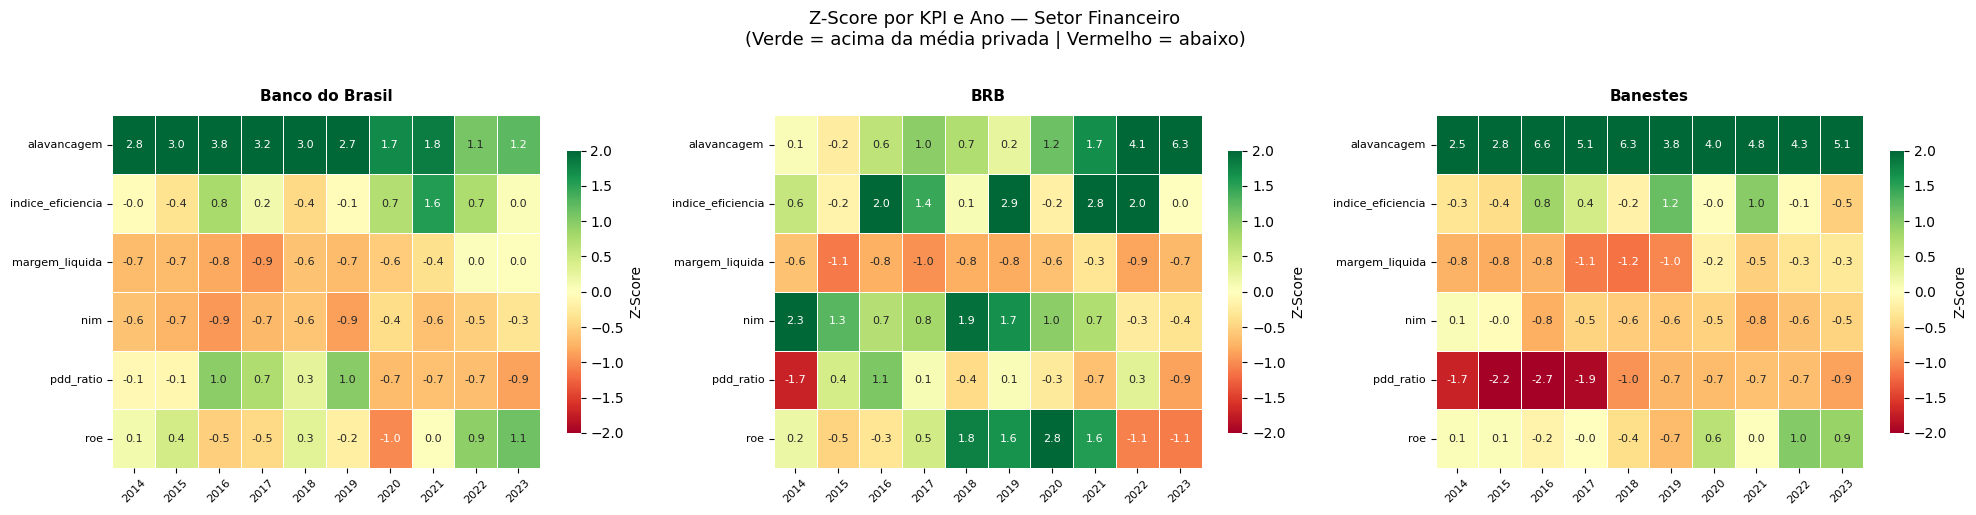

Heatmap Financeiro salvo!


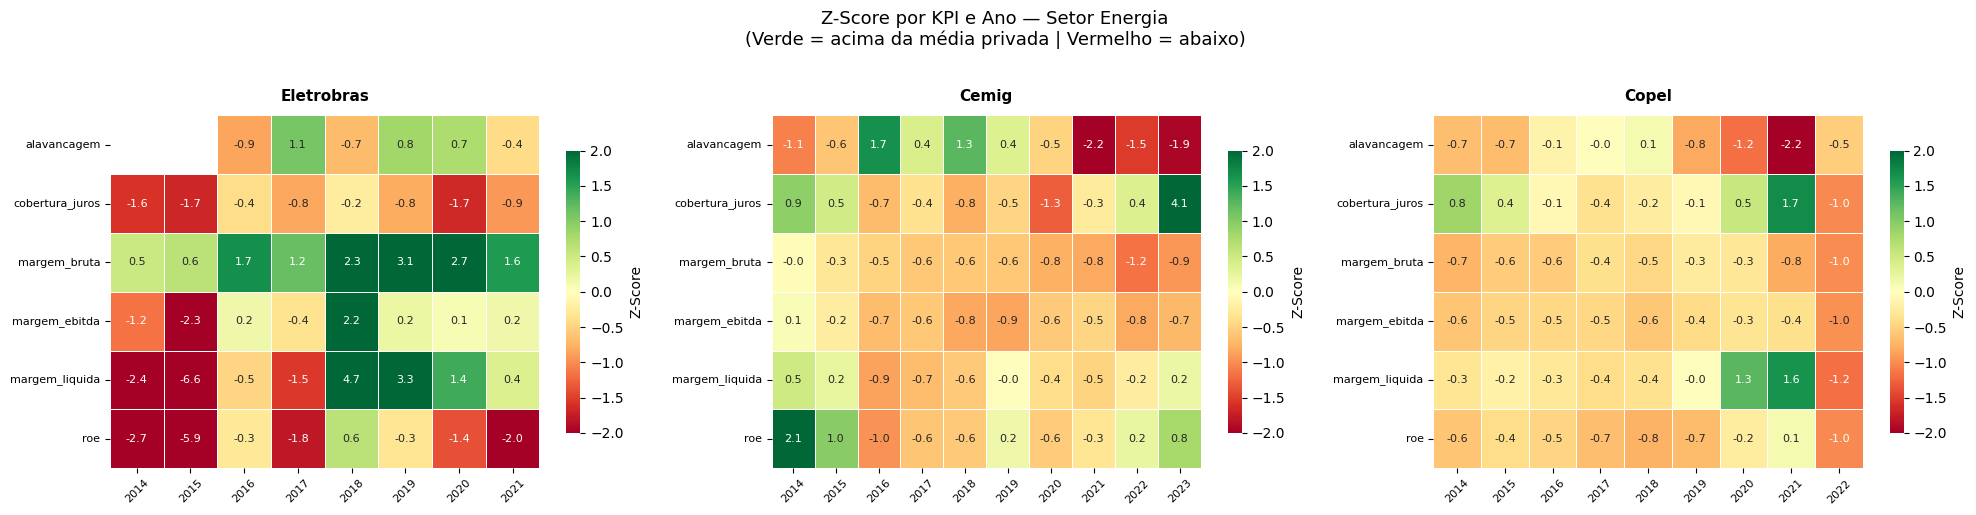

Heatmap Energia salvo!


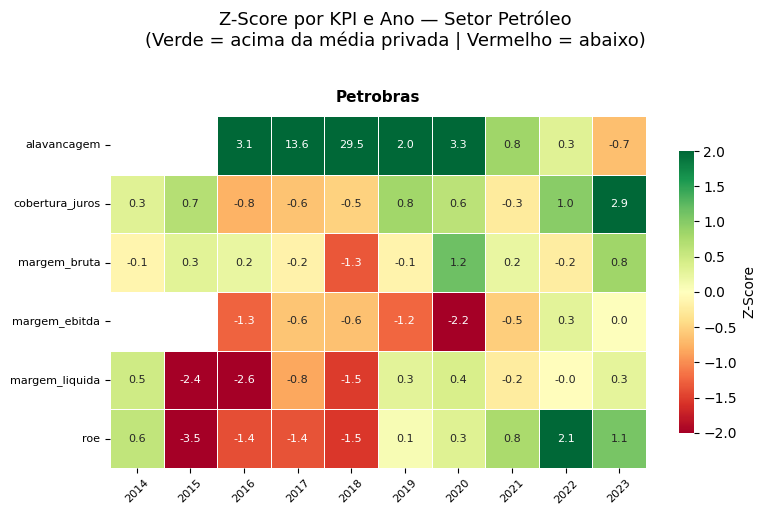

Heatmap Petróleo salvo!


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ============================================================
# GRÁFICO 1 — HEATMAP DE Z-SCORES POR ESTATAL
# Visão geral: KPI × Ano, colorido pelo Z-Score
# Verde = acima da média privada
# Vermelho = abaixo da média privada
# ============================================================

# Carregar Z-Scores
zscores_fin = pd.read_csv("../KPIs/zscores_financeiro.csv", sep=";", encoding="utf-8", keep_default_na=False)
zscores_en  = pd.read_csv("../KPIs/zscores_energia.csv",    sep=";", encoding="utf-8", keep_default_na=False)
zscores_pet = pd.read_csv("../KPIs/zscores_petroleo.csv",   sep=";", encoding="utf-8", keep_default_na=False)

# Converter zscore para numérico
for df in [zscores_fin, zscores_en, zscores_pet]:
    df['zscore'] = pd.to_numeric(df['zscore'], errors='coerce')

# Nomes curtos para o gráfico
nomes_curtos = {
    'BCO BRASIL S.A.':                                'Banco do Brasil',
    'BRB BANCO DE BRASILIA S.A.':                     'BRB',
    'BANESTES S.A. - BCO EST ESPIRITO SANTO':         'Banestes',
    'CIA ENERGETICA DE MINAS GERAIS - CEMIG':         'Cemig',
    'CIA PARANAENSE DE ENERGIA - COPEL':              'Copel',
    'CENTRAIS ELET BRAS S.A. - ELETROBRAS':           'Eletrobras',
    'PETROLEO BRASILEIRO S.A. PETROBRAS':             'Petrobras',
}

def plotar_heatmap_zscore(df_zscore, empresa, nome_curto, ax, titulo):
    """
    Plota heatmap de Z-Scores para uma empresa
    Linhas = KPIs, Colunas = Anos
    """
    # Filtrar empresa e pivotar
    emp = df_zscore[df_zscore['empresa'] == empresa].copy()
    pivot = emp.pivot(index='kpi', columns='ano', values='zscore')
    
    # Plotar heatmap
    sns.heatmap(
        pivot,
        ax=ax,
        annot=True,
        fmt='.1f',
        cmap='RdYlGn',
        vmin=-2, vmax=2,
        center=0,
        linewidths=0.5,
        cbar_kws={'shrink': 0.8, 'label': 'Z-Score'},
        annot_kws={'size': 8}
    )
    ax.set_title(titulo, fontsize=11, pad=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', rotation=0, labelsize=8)


# ============================================================
# SETOR FINANCEIRO — BB, BRB, Banestes
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Z-Score por KPI e Ano — Setor Financeiro\n(Verde = acima da média privada | Vermelho = abaixo)',
             fontsize=13, y=1.02)

empresas_fin = [
    ('BCO BRASIL S.A.',                         'Banco do Brasil'),
    ('BRB BANCO DE BRASILIA S.A.',              'BRB'),
    ('BANESTES S.A. - BCO EST ESPIRITO SANTO',  'Banestes'),
]

for i, (empresa, nome) in enumerate(empresas_fin):
    plotar_heatmap_zscore(zscores_fin, empresa, nome, axes[i], nome)

plt.tight_layout()
plt.savefig('../KPIs/heatmap_zscore_financeiro.png', dpi=150, bbox_inches='tight')
plt.show()
print("Heatmap Financeiro salvo!")


# ============================================================
# SETOR ENERGIA — Eletrobras, Cemig, Copel
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Z-Score por KPI e Ano — Setor Energia\n(Verde = acima da média privada | Vermelho = abaixo)',
             fontsize=13, y=1.02)

empresas_en = [
    ('CENTRAIS ELET BRAS S.A. - ELETROBRAS',   'Eletrobras'),
    ('CIA ENERGETICA DE MINAS GERAIS - CEMIG',  'Cemig'),
    ('CIA PARANAENSE DE ENERGIA - COPEL',       'Copel'),
]

for i, (empresa, nome) in enumerate(empresas_en):
    plotar_heatmap_zscore(zscores_en, empresa, nome, axes[i], nome)

plt.tight_layout()
plt.savefig('../KPIs/heatmap_zscore_energia.png', dpi=150, bbox_inches='tight')
plt.show()
print("Heatmap Energia salvo!")


# ============================================================
# SETOR PETRÓLEO — Petrobras
# ============================================================
fig, axes = plt.subplots(1, 1, figsize=(8, 5))
fig.suptitle('Z-Score por KPI e Ano — Setor Petróleo\n(Verde = acima da média privada | Vermelho = abaixo)',
             fontsize=13, y=1.02)

plotar_heatmap_zscore(zscores_pet, 'PETROLEO BRASILEIRO S.A. PETROBRAS', 'Petrobras', axes, 'Petrobras')

plt.tight_layout()
plt.savefig('../KPIs/heatmap_zscore_petroleo.png', dpi=150, bbox_inches='tight')
plt.show()
print("Heatmap Petróleo salvo!")

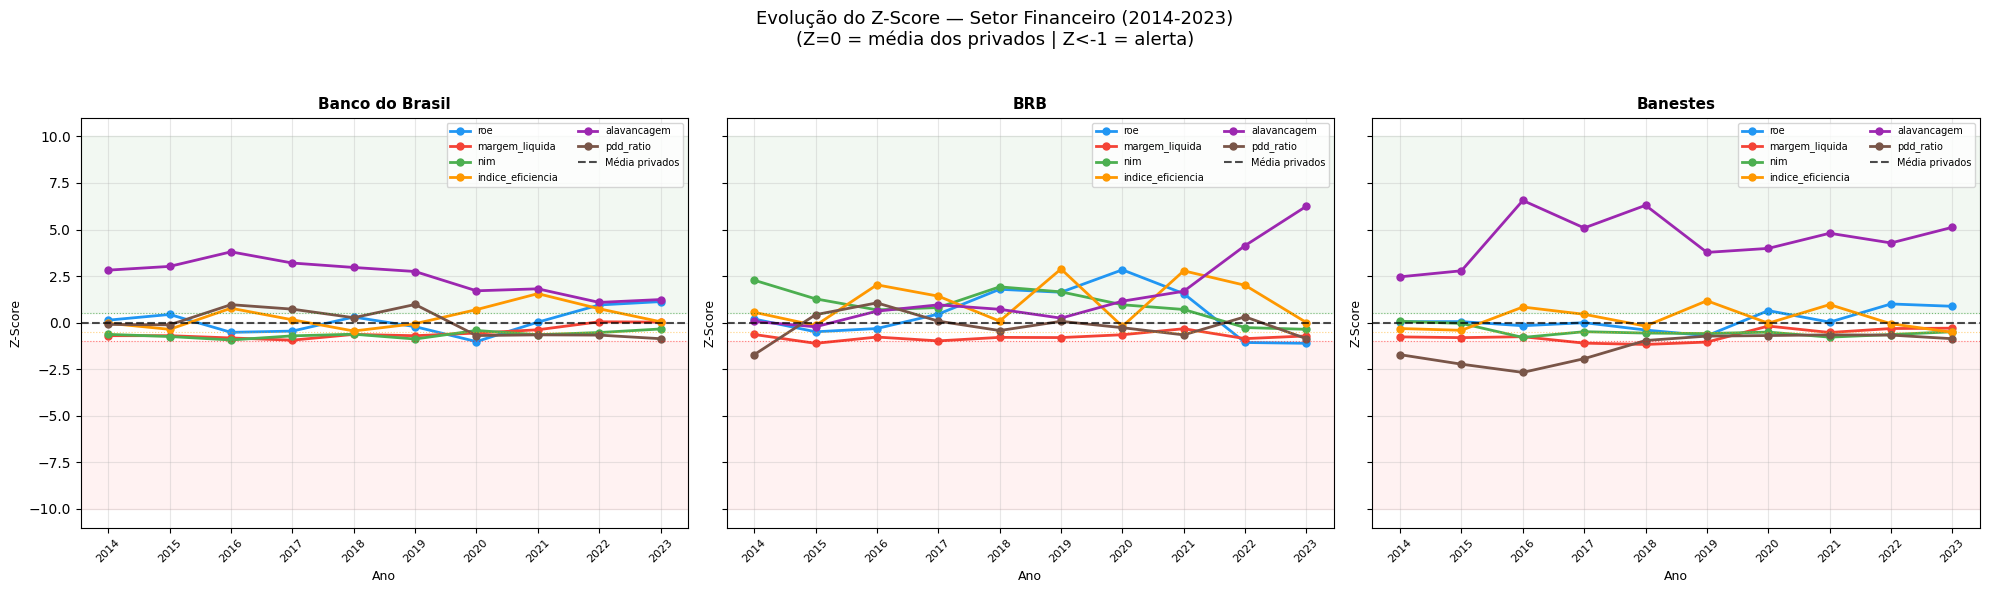

Gráfico Financeiro salvo!


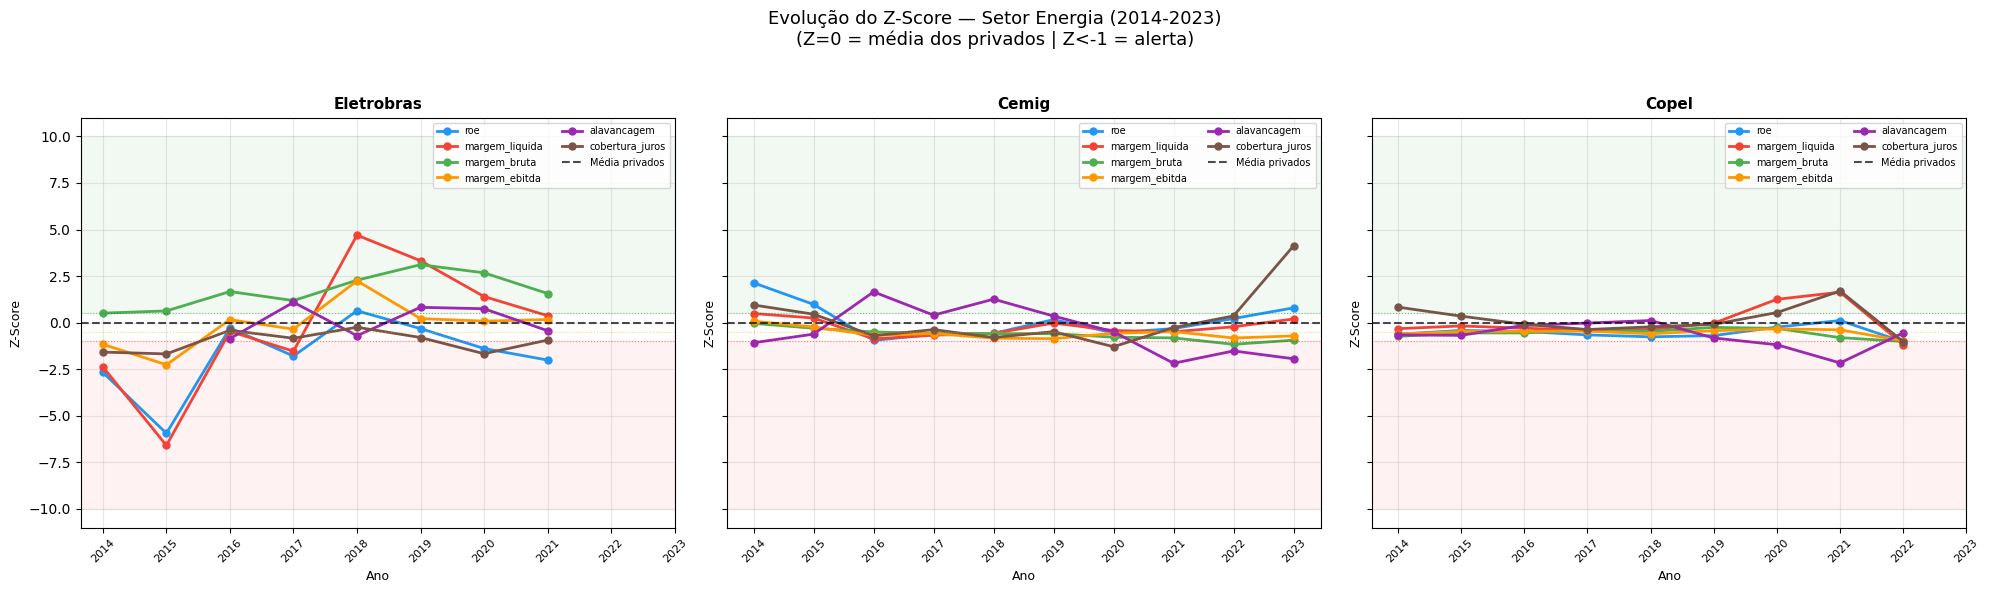

Gráfico Energia salvo!


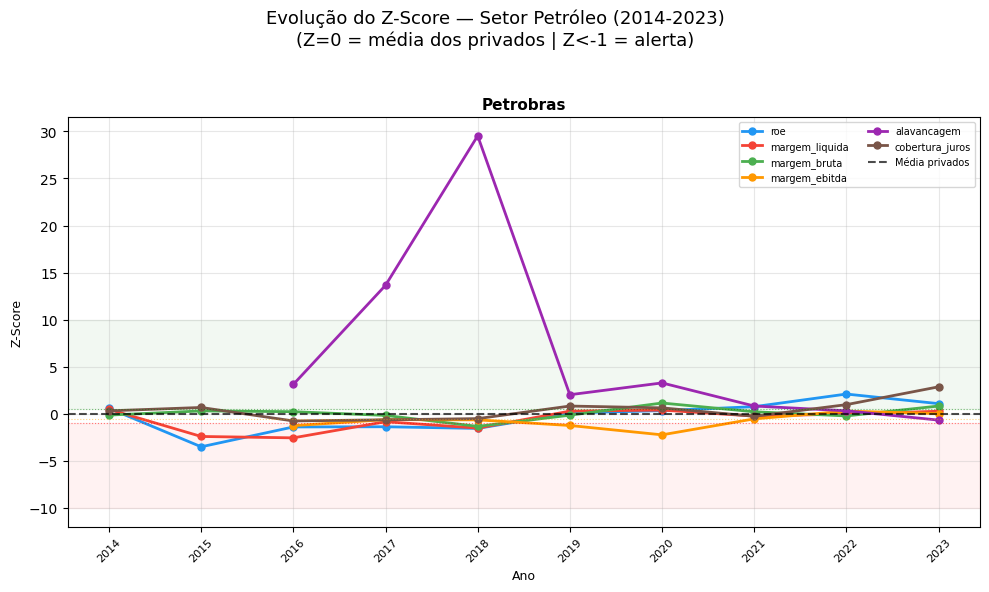

Gráfico Petróleo salvo!


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ============================================================
# GRÁFICO 2 — EVOLUÇÃO DO Z-SCORE AO LONGO DO TEMPO
# Linha por KPI para cada estatal
# Mostra tendência temporal do desempenho relativo
# ============================================================

# Cores por KPI
cores_kpi_fin = {
    'roe':               '#2196F3',
    'margem_liquida':    '#F44336',
    'nim':               '#4CAF50',
    'indice_eficiencia': '#FF9800',
    'alavancagem':       '#9C27B0',
    'pdd_ratio':         '#795548',
}

cores_kpi_en = {
    'roe':             '#2196F3',
    'margem_liquida':  '#F44336',
    'margem_bruta':    '#4CAF50',
    'margem_ebitda':   '#FF9800',
    'alavancagem':     '#9C27B0',
    'cobertura_juros': '#795548',
}

def plotar_evolucao_zscore(df_zscore, empresa, nome, cols, cores, ax):
    """
    Plota a evolução do Z-Score ao longo do tempo para cada KPI
    """
    emp = df_zscore[df_zscore['empresa'] == empresa].copy()
    emp['zscore'] = pd.to_numeric(emp['zscore'], errors='coerce')

    for kpi in cols:
        dados = emp[emp['kpi'] == kpi].sort_values('ano')
        ax.plot(
            dados['ano'],
            dados['zscore'],
            marker='o',
            linewidth=2,
            markersize=5,
            label=kpi,
            color=cores.get(kpi, 'gray')
        )

    # Linha de referência — média dos privados (Z=0)
    ax.axhline(y=0,   color='black', linewidth=1.5, linestyle='--', alpha=0.7, label='Média privados')
    ax.axhline(y=0.5, color='green', linewidth=0.8, linestyle=':',  alpha=0.5)
    ax.axhline(y=-0.5,color='orange',linewidth=0.8, linestyle=':',  alpha=0.5)
    ax.axhline(y=-1,  color='red',   linewidth=0.8, linestyle=':',  alpha=0.5)

    # Zona de alerta (coloquei valores altos/baixos como 10 e -10 para garantir que pinte o fundo todo, 
    # mesmo se o gráfico auto-escalar para valores muito grandes)
    ax.axhspan(-1, -10, alpha=0.05, color='red')
    ax.axhspan(0.5, 10, alpha=0.05, color='green')

    ax.set_title(nome, fontsize=11, fontweight='bold')
    ax.set_xlabel('Ano', fontsize=9)
    ax.set_ylabel('Z-Score', fontsize=9)
    ax.set_xticks(range(2014, 2024))
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    
    # Mudei de 'upper left' para 'best'
    ax.legend(fontsize=7, loc='best', ncol=2)
    
    ax.grid(True, alpha=0.3)
    
    # Remova ou comente a linha abaixo para o gráfico parar de cortar as linhas:
    # ax.set_ylim(-3, 4)


# --- Financeiro ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
fig.suptitle('Evolução do Z-Score — Setor Financeiro (2014-2023)\n(Z=0 = média dos privados | Z<-1 = alerta)',
             fontsize=13)

empresas_fin = [
    ('BCO BRASIL S.A.',                        'Banco do Brasil'),
    ('BRB BANCO DE BRASILIA S.A.',             'BRB'),
    ('BANESTES S.A. - BCO EST ESPIRITO SANTO', 'Banestes'),
]
for i, (empresa, nome) in enumerate(empresas_fin):
    plotar_evolucao_zscore(zscores_fin, empresa, nome, list(cores_kpi_fin.keys()), cores_kpi_fin, axes[i])

plt.tight_layout(rect=[0, 0, 1, 0.95]) # O 0.95 avisa para deixar 5% do topo livre para o Suptitle
plt.savefig('../KPIs/evolucao_zscore_financeiro.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico Financeiro salvo!")


# --- Energia ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
fig.suptitle('Evolução do Z-Score — Setor Energia (2014-2023)\n(Z=0 = média dos privados | Z<-1 = alerta)',
             fontsize=13)

empresas_en = [
    ('CENTRAIS ELET BRAS S.A. - ELETROBRAS',  'Eletrobras'),
    ('CIA ENERGETICA DE MINAS GERAIS - CEMIG', 'Cemig'),
    ('CIA PARANAENSE DE ENERGIA - COPEL',      'Copel'),
]
for i, (empresa, nome) in enumerate(empresas_en):
    plotar_evolucao_zscore(zscores_en, empresa, nome, list(cores_kpi_en.keys()), cores_kpi_en, axes[i])

plt.tight_layout(rect=[0, 0, 1, 0.95]) # O 0.95 avisa para deixar 5% do topo livre para o Suptitle
plt.savefig('../KPIs/evolucao_zscore_energia.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico Energia salvo!")


# --- Petróleo ---
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
fig.suptitle('Evolução do Z-Score — Setor Petróleo (2014-2023)\n(Z=0 = média dos privados | Z<-1 = alerta)',
             fontsize=13)

plotar_evolucao_zscore(zscores_pet, 'PETROLEO BRASILEIRO S.A. PETROBRAS', 'Petrobras',
                       list(cores_kpi_en.keys()), cores_kpi_en, ax)

plt.tight_layout(rect=[0, 0, 1, 0.95]) # O 0.95 avisa para deixar 5% do topo livre para o Suptitle
plt.savefig('../KPIs/evolucao_zscore_petroleo.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico Petróleo salvo!")

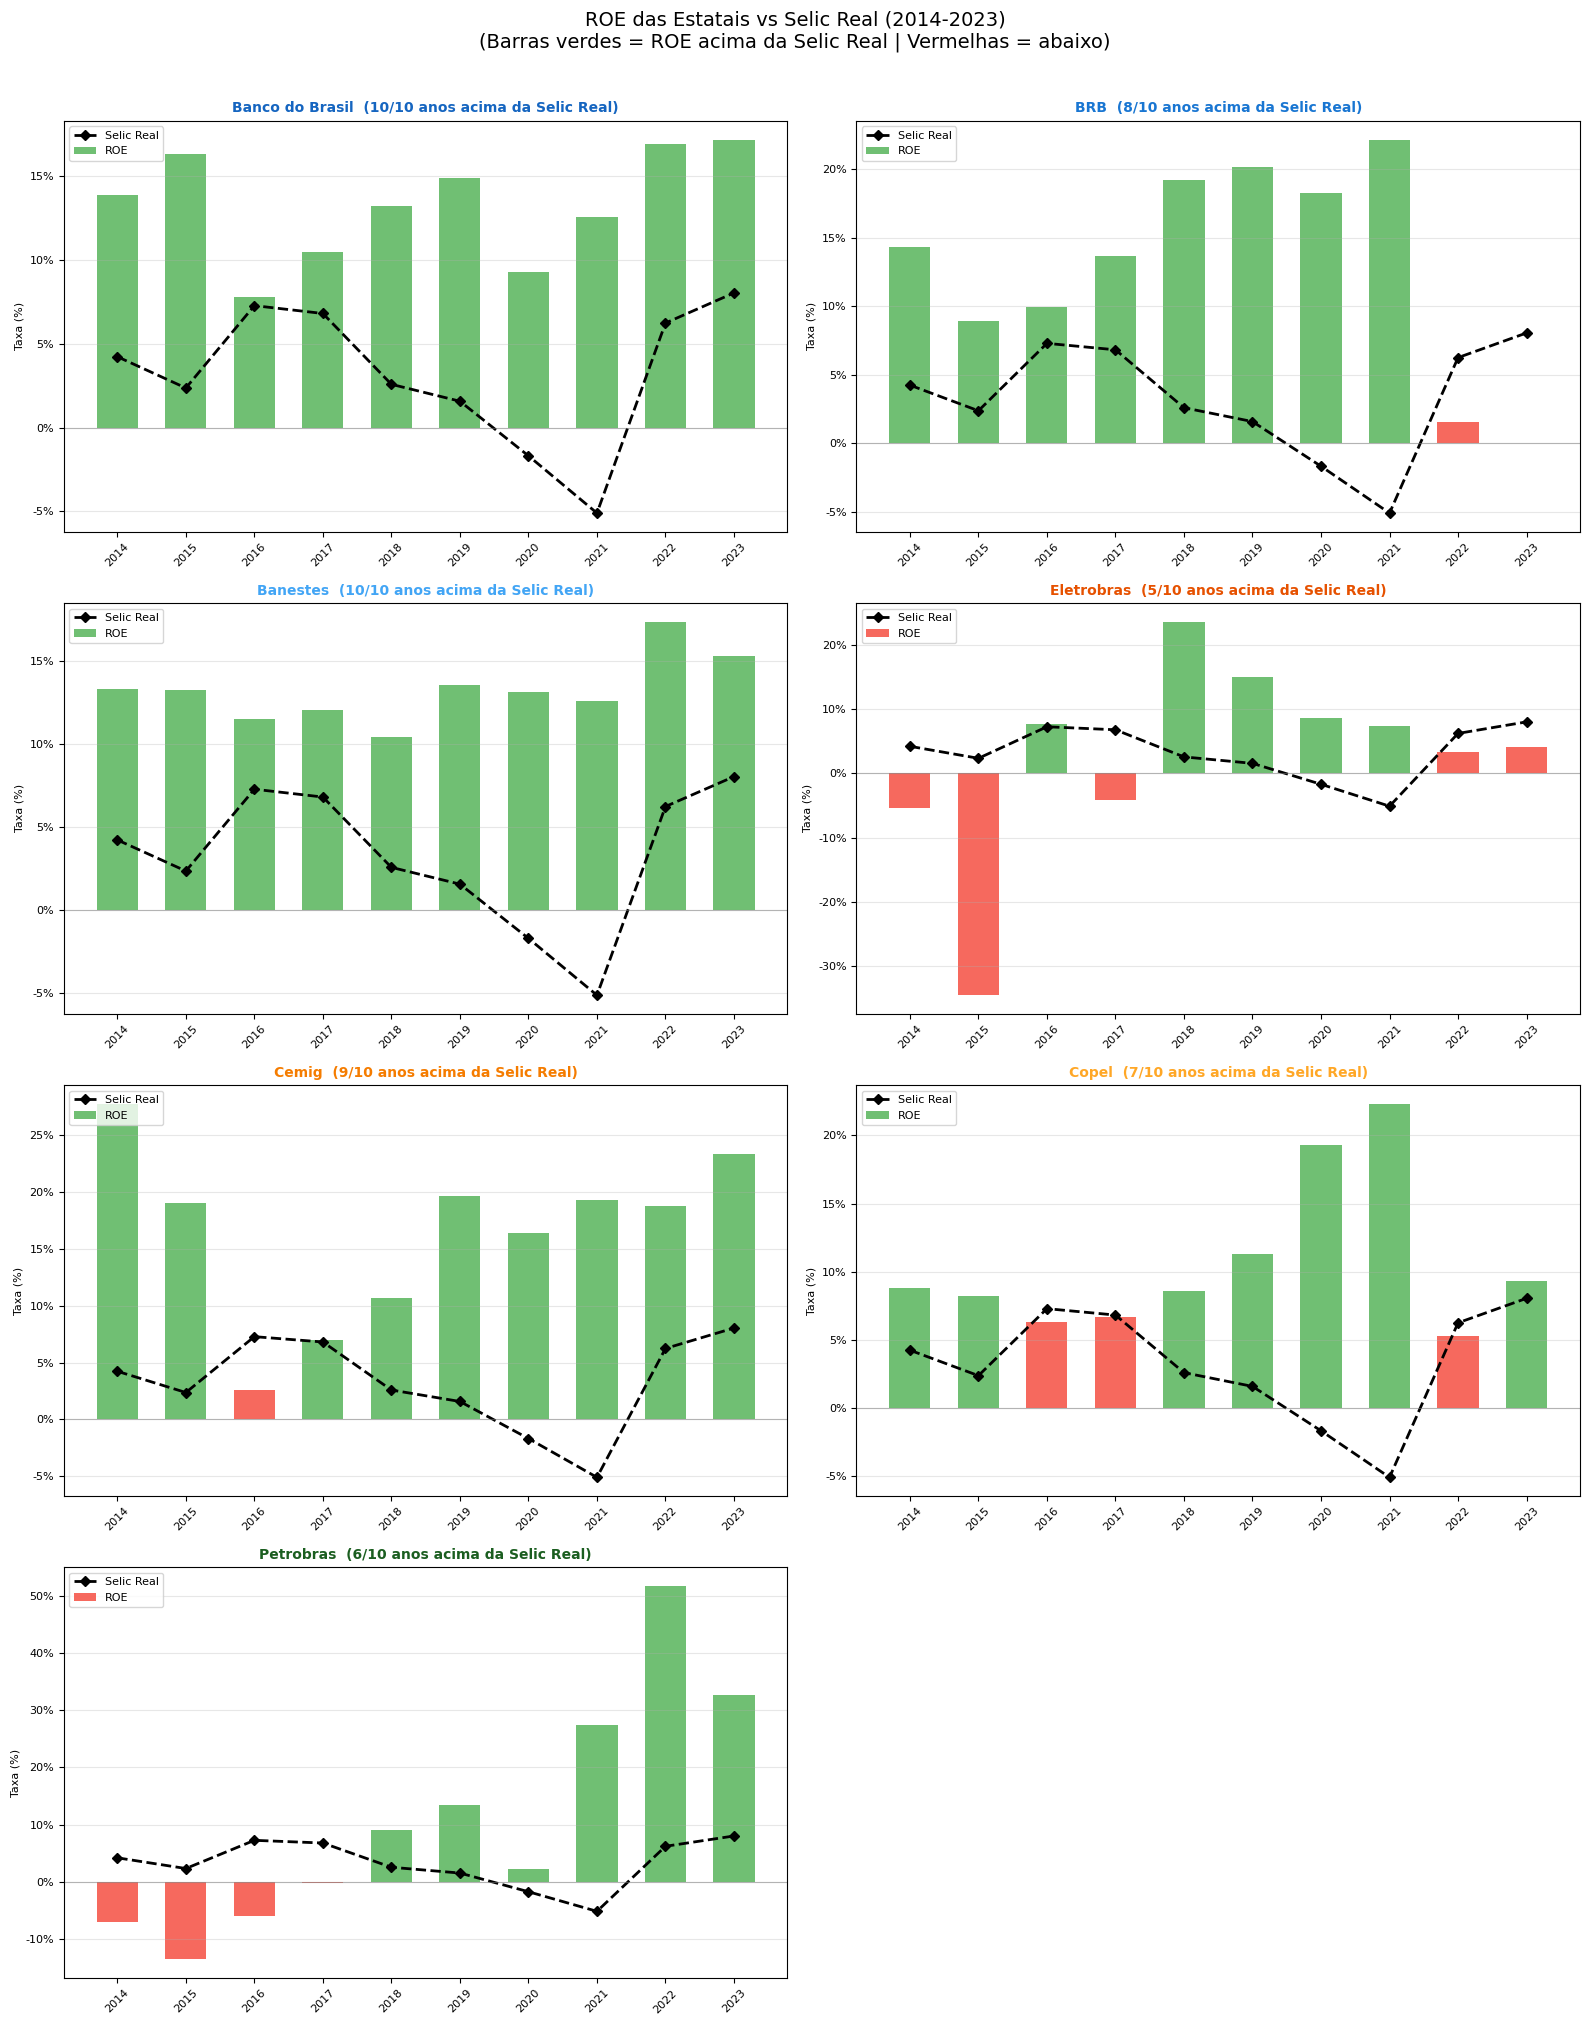

Gráfico ROE vs Selic Real salvo!


In [20]:
# ============================================================
# GRÁFICO 3 — ROE vs SELIC REAL POR ESTATAL
# Barras do ROE vs linha da Selic Real
# Mostra se cada estatal criou valor real acima do
# custo de oportunidade do capital sem risco
# ============================================================

macro = pd.read_csv("../Dados_macroeconomicos/macro_anual.csv", sep=";", encoding="utf-8")

# Todas as estatais e seus setores
estatais_info = [
    ('BCO BRASIL S.A.',                         'Banco do Brasil',  kpis_fin, '#1565C0'),
    ('BRB BANCO DE BRASILIA S.A.',              'BRB',              kpis_fin, '#1976D2'),
    ('BANESTES S.A. - BCO EST ESPIRITO SANTO',  'Banestes',         kpis_fin, '#42A5F5'),
    ('CENTRAIS ELET BRAS S.A. - ELETROBRAS',    'Eletrobras',       kpis_en,  '#E65100'),
    ('CIA ENERGETICA DE MINAS GERAIS - CEMIG',  'Cemig',            kpis_en,  '#F57C00'),
    ('CIA PARANAENSE DE ENERGIA - COPEL',       'Copel',            kpis_en,  '#FFA726'),
    ('PETROLEO BRASILEIRO S.A. PETROBRAS',      'Petrobras',        kpis_pet, '#1B5E20'),
]

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
fig.suptitle('ROE das Estatais vs Selic Real (2014-2023)\n(Barras verdes = ROE acima da Selic Real | Vermelhas = abaixo)',
             fontsize=14, y=1.01)

axes_flat = axes.flatten()

# Esconder o último subplot (7 empresas, 8 subplots)
axes_flat[7].set_visible(False)

anos = list(range(2014, 2024))

for idx, (empresa, nome, df_kpi, cor) in enumerate(estatais_info):
    ax = axes_flat[idx]
    
    # Dados da empresa
    emp = df_kpi[df_kpi['empresa'] == empresa][['ano', 'roe']].copy()
    emp['roe'] = pd.to_numeric(emp['roe'], errors='coerce')
    emp = emp.merge(macro[['ano', 'selic_real']], on='ano')
    emp['selic_real_dec'] = emp['selic_real'] / 100
    emp['bate'] = emp['roe'] > emp['selic_real_dec']
    
    # Cores das barras — verde se bate, vermelho se não bate
    cores_barras = ['#4CAF50' if b else '#F44336' for b in emp['bate']]
    
    # Plotar barras do ROE
    bars = ax.bar(
        emp['ano'],
        emp['roe'],
        color=cores_barras,
        alpha=0.8,
        width=0.6,
        label='ROE'
    )
    
    # Linha da Selic Real
    ax.plot(
        emp['ano'],
        emp['selic_real_dec'],
        color='black',
        linewidth=2,
        marker='D',
        markersize=5,
        linestyle='--',
        label='Selic Real'
    )
    
    # Linha de referência em zero
    ax.axhline(y=0, color='gray', linewidth=0.8, linestyle='-', alpha=0.5)
    
    # Contagem de anos que bate
    n_bate = emp['bate'].sum()
    n_total = len(emp)
    
    ax.set_title(f'{nome}  ({n_bate}/{n_total} anos acima da Selic Real)',
                 fontsize=10, fontweight='bold', color=cor)
    ax.set_xticks(anos)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)
    ax.set_ylabel('Taxa (%)', fontsize=8)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../KPIs/roe_vs_selic_real.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico ROE vs Selic Real salvo!")

C:\Users\Thallesfb\AppData\Local\Temp\ipykernel_3476\3602223310.py:101: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Thallesfb\AppData\Local\Temp\ipykernel_3476\3602223310.py:102: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('../KPIs/boxplot_estatais_vs_privados.png', dpi=150, bbox_inches='tight')
c:\Users\Thallesfb\Desktop\FodaseEstatais2\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


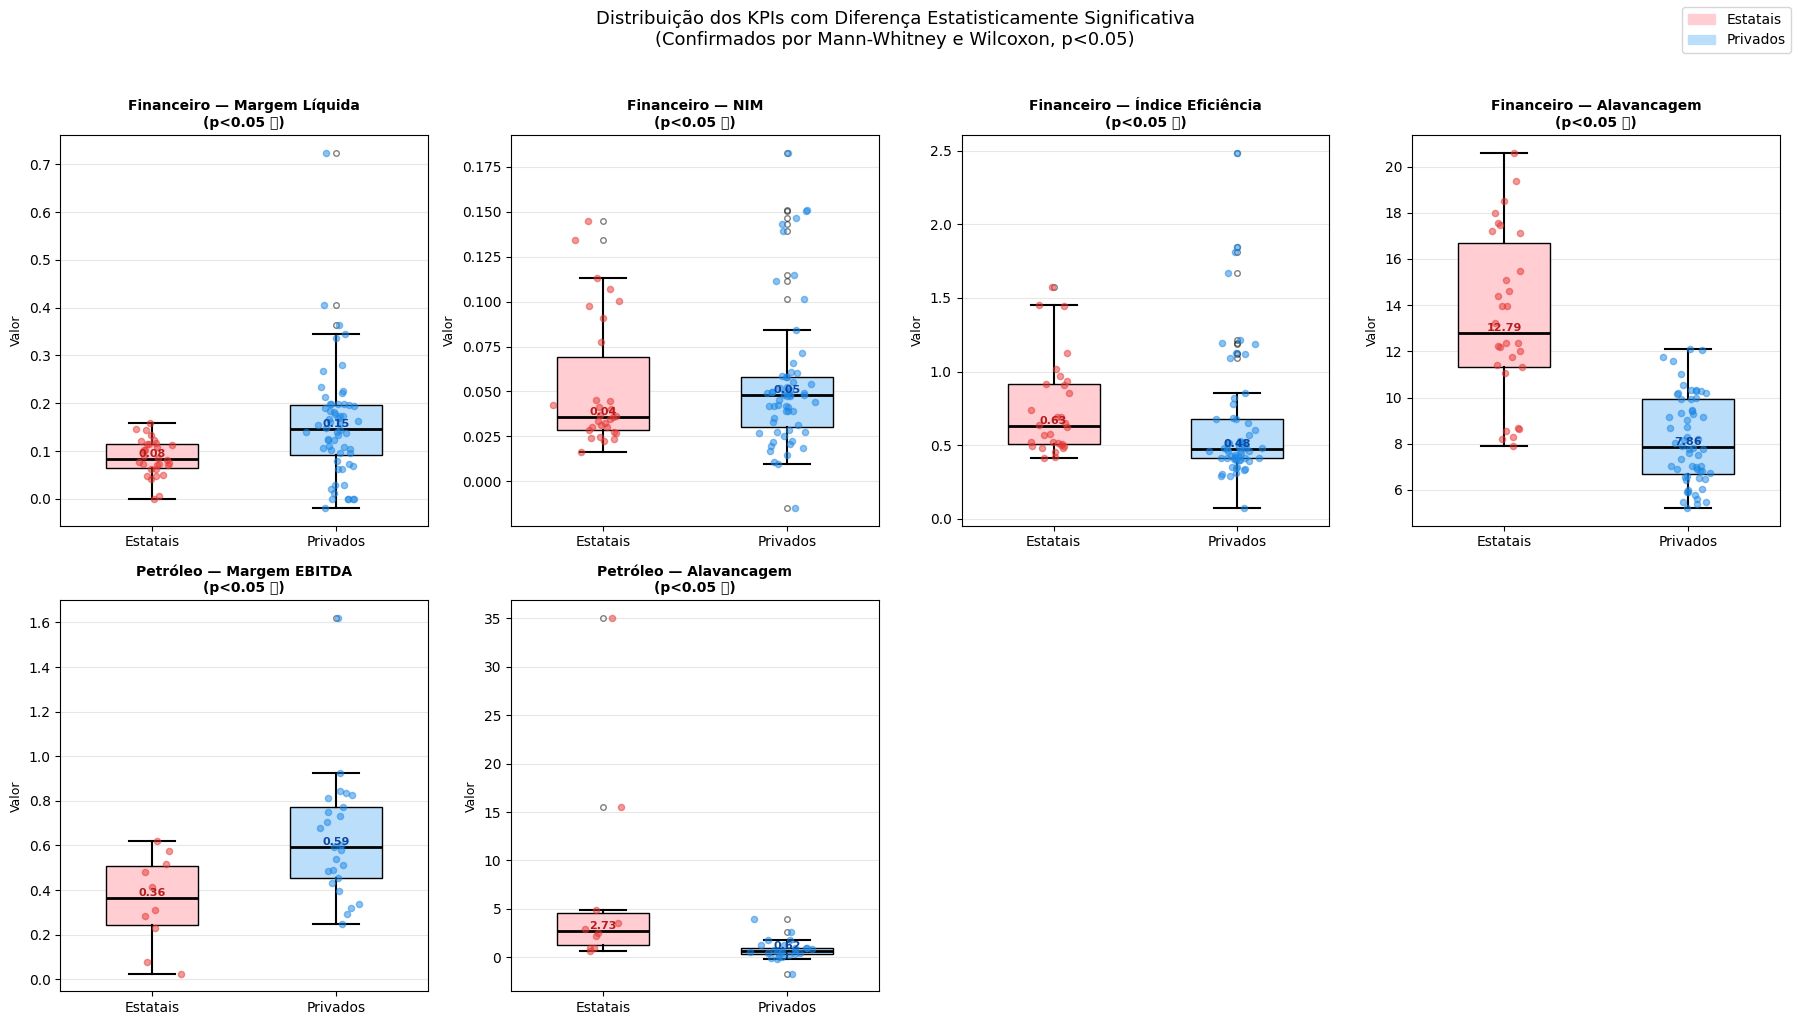

Boxplot salvo!


In [ ]:
# ============================================================
# GRÁFICO 4 — BOXPLOT ESTATAIS vs PRIVADOS
# Mostra a distribuição dos KPIs confirmados pelo Wilcoxon
# Visualiza graficamente as diferenças estatisticamente
# significativas encontradas nos testes
# ============================================================

# KPIs confirmados por ambos os testes (Mann-Whitney + Wilcoxon)
kpis_confirmados = {
    'Financeiro': {
        'df':   kpis_fin,
        'kpis': ['margem_liquida', 'nim', 'indice_eficiencia', 'alavancagem'],
        'nomes':['Margem Líquida', 'NIM', 'Índice Eficiência', 'Alavancagem'],
    },
    'Energia': {
        'df':   kpis_en,
        'kpis': [],  # nenhum confirmado
        'nomes':[],
    },
    'Petróleo': {
        'df':   kpis_pet,
        'kpis': ['margem_ebitda', 'alavancagem'],
        'nomes':['Margem EBITDA', 'Alavancagem'],
    },
}

# Plotar só setores com KPIs confirmados
setores_com_kpis = {k: v for k, v in kpis_confirmados.items() if len(v['kpis']) > 0}

fig, axes = plt.subplots(
    len(setores_com_kpis),
    max(len(v['kpis']) for v in setores_com_kpis.values()),
    figsize=(18, 10)
)

cores = {'Estatal': '#E53935', 'Privado': '#1E88E5'}

for row, (setor, info) in enumerate(setores_com_kpis.items()):
    df   = info['df'].copy()
    kpis = info['kpis']
    nomes= info['nomes']

    # Converter KPIs para numérico
    for kpi in kpis:
        df[kpi] = pd.to_numeric(df[kpi], errors='coerce')

    for col, (kpi, nome_kpi) in enumerate(zip(kpis, nomes)):
        ax = axes[row][col] if len(setores_com_kpis) > 1 else axes[col]

        # Dados por tipo
        estatais = df[df['tipo'] == 'Estatal'][kpi].dropna()
        privados = df[df['tipo'] == 'Privado'][kpi].dropna()

        # Boxplot
        bp = ax.boxplot(
            [estatais, privados],
            tick_labels=['Estatais', 'Privados'],
            patch_artist=True,
            medianprops={'color': 'black', 'linewidth': 2},
            whiskerprops={'linewidth': 1.5},
            capprops={'linewidth': 1.5},
            flierprops={'marker': 'o', 'markersize': 4, 'alpha': 0.5},
            widths=0.5,
        )

        # Colorir caixas
        bp['boxes'][0].set_facecolor('#FFCDD2')  # estatal = vermelho claro
        bp['boxes'][1].set_facecolor('#BBDEFB')  # privado = azul claro

        # Adicionar pontos individuais (jitter)
        for i, dados in enumerate([estatais, privados], 1):
            x_jitter = np.random.normal(i, 0.06, size=len(dados))
            cor = '#E53935' if i == 1 else '#1E88E5'
            ax.scatter(x_jitter, dados, alpha=0.5, s=20, color=cor, zorder=3)

        # Mediana como texto
        med_est = estatais.median()
        med_priv = privados.median()
        ax.text(1, med_est, f'{med_est:.2f}', ha='center', va='bottom',
                fontsize=8, color='#B71C1C', fontweight='bold')
        ax.text(2, med_priv, f'{med_priv:.2f}', ha='center', va='bottom',
                fontsize=8, color='#0D47A1', fontweight='bold')

        ax.set_title(f'{setor} — {nome_kpi}\n(p<0.05)', fontsize=10, fontweight='bold')
        ax.set_ylabel('Valor', fontsize=9)
        ax.grid(True, alpha=0.3, axis='y')

    # Esconder subplots vazios
    if len(kpis) < axes.shape[1] if hasattr(axes, 'shape') else 0:
        for col in range(len(kpis), axes.shape[1]):
            axes[row][col].set_visible(False)

# Legenda geral
patch_est  = mpatches.Patch(color='#FFCDD2', label='Estatais')
patch_priv = mpatches.Patch(color='#BBDEFB', label='Privados')
fig.legend(handles=[patch_est, patch_priv], loc='upper right', fontsize=10)

fig.suptitle('Distribuição dos KPIs com Diferença Estatisticamente Significativa\n(Confirmados por Mann-Whitney e Wilcoxon, p<0.05)',
             fontsize=13, y=1.02)

plt.tight_layout()
plt.savefig('../KPIs/boxplot_estatais_vs_privados.png', dpi=150, bbox_inches='tight')
plt.show()
print("Boxplot salvo!")